In [1]:
# Testing objective function output

import desc.io
from desc.objectives import (
    TrappedResonance
)
import numpy as np
eq_init = desc.io.load("desc_eq_new_QH_aScaling.h5")
obj = TrappedResonance(eq_init)
# grid is set in init of TrappedResonance class
obj.build()
value = obj.compute(eq_init.params_dict)
# value = eq_init.compute('f_tr',grid=grid)

print(value)
# print(np.shape(value['alpha_drift_avg']))


Precomputing transforms
[8.29351272e-09 6.51350829e-11 1.15370163e-11]


In [ ]:
print(value.shape)

In [7]:
# debug cell (restart kernel and run before running optimizer)
import sys
import os
import math

sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../../../"))
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 20

import desc.io
from desc.grid import LinearGrid, ConcentricGrid
from desc.objectives import (
    ObjectiveFunction,
    FixBoundaryR,
    FixBoundaryZ,
    FixPressure,
    FixIota,
    FixPsi,
    AspectRatio,
    ForceBalance,
    QuasisymmetryBoozer,
    QuasisymmetryTwoTerm,
    QuasisymmetryTripleProduct,
    ObjectiveFromUser,
    GammaC,
    TrappedResonance
)
from desc.optimize import Optimizer
from desc.plotting import (
    plot_grid,
    plot_boozer_modes,
    plot_boozer_surface,
    plot_qs_error,
    plot_boundaries,
    plot_boundary,
)
# load initial equilibrium
# eq_init = desc.io.load("qs_initial_guess.h5") # QI
eq_init = desc.io.load("desc_eq_new_QH_aScaling.h5") # QH

# Specify equilibrium nfp and helicity
N = -1 # QH helicity
# N = 0 # QA
nfp = eq_init.NFP
s_input = np.linspace(0.1,0.9,3) # surfaces to test, rho = sqrt(s) is calculated below. DESC 

optimizer = Optimizer("proximal-scipy-bfgs")

# indices of boundary modes we want to optimize
idx_Rcc = eq_init.surface.R_basis.get_idx(M=1, N=2)
idx_Rss = eq_init.surface.R_basis.get_idx(M=-1, N=-2)
idx_Zsc = eq_init.surface.Z_basis.get_idx(M=-1, N=2)
idx_Zcs = eq_init.surface.Z_basis.get_idx(M=1, N=-2)
print("surface.R_basis.modes is an array of [l,m,n] of the surface modes:")
print(eq_init.surface.R_basis.modes[0:10])

# boundary modes to constrain
R_modes = np.delete(eq_init.surface.R_basis.modes, [idx_Rcc, idx_Rss], axis=0)
Z_modes = np.delete(eq_init.surface.Z_basis.modes, [idx_Zsc, idx_Zcs], axis=0)

eq_qs_T = eq_init.copy()  # make a copy of the original one
# constraints
constraints = (
    ForceBalance(eq=eq_qs_T),  # enforce JxB-grad(p)=0 during optimization
    FixBoundaryR(eq=eq_qs_T, modes=R_modes),  # fix specified R boundary modes
    FixBoundaryZ(eq=eq_qs_T, modes=Z_modes),  # fix specified Z boundary modes
    FixPressure(eq=eq_qs_T),  # fix pressure profile
    FixIota(eq=eq_qs_T),  # fix rotational transform profile
    FixPsi(eq=eq_qs_T),  # fix total toroidal magnetic flux
)

# Create a grid in (rho, theta, zeta) coordinates
# rho = np.linspace(0.1,0.9,5)
rho=abs(np.sqrt(s_input))
eq_periodicity = (np.inf,np.inf,np.inf) # periodicity in zeta for these equilibrium to make rtz grid
grid = eq_init._get_rtz_grid( # returns rho, theta, zeta coordinate grid
    rho, # radial
    np.array([0]), # poloidal (alpha in this case)
    np.linspace(0, 12 * np.pi, 300), # toroidal (zeta in this case)
    coordinates="raz", # rho, alpha, zeta input coordinates
    period=eq_periodicity, # periodicity of coordinate (rho,alpha,zeta)
)
# grid has the number of nodes equal to len(rho)*len(alpha)*length(zeta)

# Grid for QuasisymmetryTripleProduct objective
grid_vol = ConcentricGrid(
    L=eq_init.L_grid,
    M=eq_init.M_grid,
    N=eq_init.N_grid,
    NFP=eq_init.NFP,
    sym=eq_init.sym,
)

# Objective for resonance
objective_fT = ObjectiveFunction(
    (
        QuasisymmetryTripleProduct(eq=eq_qs_T, grid=grid_vol),
        # TrappedResonance(eq=eq_qs_T, grid=grid)
    ), 
)

surface.R_basis.modes is an array of [l,m,n] of the surface modes:
[[ 0 -7 -8]
 [ 0 -6 -8]
 [ 0 -5 -8]
 [ 0 -4 -8]
 [ 0 -3 -8]
 [ 0 -2 -8]
 [ 0 -1 -8]
 [ 0 -7 -7]
 [ 0 -6 -7]
 [ 0 -5 -7]]


In [8]:
eq_qs_T, result_T = eq_qs_T.optimize(
    objective=objective_fT,
    constraints=constraints,
    optimizer=optimizer,
    ftol=5e-2,  # stopping tolerance on the function value
    xtol=1e-6,  # stopping tolerance on the step size
    gtol=1e-6,  # stopping tolerance on the gradient
    maxiter=10,  # maximum number of iterations
    options={
        "perturb_options": {"order": 2, "verbose": 0},  # use 2nd-order perturbations
        "solve_options": {
            "ftol": 5e-3,
            "xtol": 1e-6,
            "gtol": 1e-6,
            "verbose": 0,
        },  # for equilibrium subproblem
    },
    copy=False,  # copy=False we will overwrite the eq_qs_T object with the optimized result
    verbose=3,
)

Building objective: QS triple product
Precomputing transforms
Timer: Precomputing transforms = 93.1 ms
Timer: Objective build = 237 ms
Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 42.3 ms
Timer: Objective build = 53.5 ms
Timer: Objective build = 1.23 ms
Timer: Eq Update LinearConstraintProjection build = 224 ms
Timer: Proximal projection build = 855 ms
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed pressure
Building objective: fixed iota
Building objective: fixed Psi
Timer: Objective build = 86.3 ms
Timer: LinearConstraintProjection build = 150 ms
Number of parameters: 4
Number of objectives: 2112
Timer: Initializing the optimization = 1.11 sec

Starting optimization
Using method: proximal-scipy-bfgs
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1          8.442e-07                                    3.067e-04   
         Current function value: 8.44

: 

TESTING THE DESC TUTORIAL "DESC_TrappedRes/docs/notebooks/tutorials/basic_optimization.ipynb"

surface.R_basis.modes is an array of [l,m,n] of the surface modes:
[[ 0 -8 -4]
 [ 0 -7 -4]
 [ 0 -6 -4]
 [ 0 -5 -4]
 [ 0 -4 -4]
 [ 0 -3 -4]
 [ 0 -2 -4]
 [ 0 -1 -4]
 [ 0 -8 -3]
 [ 0 -7 -3]]
Building objective: QS triple product
Precomputing transforms
Timer: Precomputing transforms = 504 ms
Timer: Objective build = 759 ms
Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 177 ms
Timer: Objective build = 196 ms
Timer: Objective build = 1.06 ms
Timer: Eq Update LinearConstraintProjection build = 1.65 sec
Timer: Proximal projection build = 3.48 sec
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed pressure
Building objective: fixed iota
Building objective: fixed Psi
Timer: Objective build = 306 ms
Timer: LinearConstraintProjection build = 589 ms
Number of parameters: 4
Number of objectives: 1377
Timer: Initializing the optimization = 4.41 sec

Starting optimization
Using method: proximal-lsq-exact
   Iteration     Total nfev     

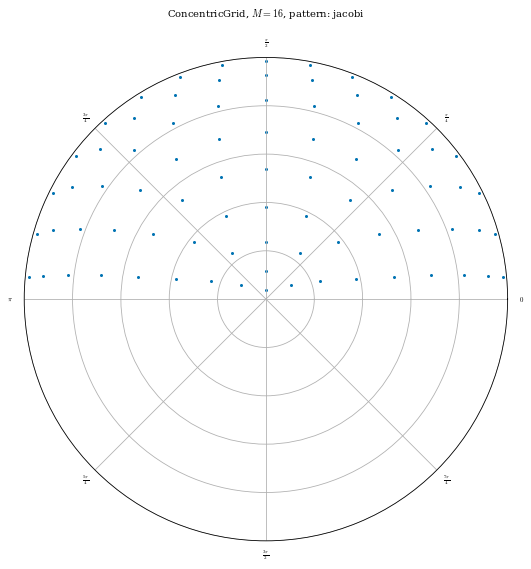

In [1]:
# Copy the basic_optimization.ipynb code here

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 20

import desc.io
from desc.grid import LinearGrid, ConcentricGrid
from desc.objectives import (
    ObjectiveFunction,
    FixBoundaryR,
    FixBoundaryZ,
    FixPressure,
    FixIota,
    FixPsi,
    AspectRatio,
    ForceBalance,
    QuasisymmetryBoozer,
    QuasisymmetryTwoTerm,
    QuasisymmetryTripleProduct,
)
from desc.optimize import Optimizer
from desc.plotting import (
    plot_grid,
    plot_boozer_modes,
    plot_boozer_surface,
    plot_qs_error,
    plot_boundaries,
    plot_boundary,
)

# load initial equilibrium
eq_init = desc.io.load("qs_initial_guess.h5")

optimizer = Optimizer("proximal-lsq-exact")

# indices of boundary modes we want to optimize
idx_Rcc = eq_init.surface.R_basis.get_idx(M=1, N=2)
idx_Rss = eq_init.surface.R_basis.get_idx(M=-1, N=-2)
idx_Zsc = eq_init.surface.Z_basis.get_idx(M=-1, N=2)
idx_Zcs = eq_init.surface.Z_basis.get_idx(M=1, N=-2)
print("surface.R_basis.modes is an array of [l,m,n] of the surface modes:")
print(eq_init.surface.R_basis.modes[0:10])

# boundary modes to constrain
R_modes = np.delete(eq_init.surface.R_basis.modes, [idx_Rcc, idx_Rss], axis=0)
Z_modes = np.delete(eq_init.surface.Z_basis.modes, [idx_Zsc, idx_Zcs], axis=0)

eq_qs_T = eq_init.copy()  # make a copy of the original one
# constraints
constraints = (
    ForceBalance(eq=eq_qs_T),  # enforce JxB-grad(p)=0 during optimization
    FixBoundaryR(eq=eq_qs_T, modes=R_modes),  # fix specified R boundary modes
    FixBoundaryZ(eq=eq_qs_T, modes=Z_modes),  # fix specified Z boundary modes
    FixPressure(eq=eq_qs_T),  # fix pressure profile
    FixIota(eq=eq_qs_T),  # fix rotational transform profile
    FixPsi(eq=eq_qs_T),  # fix total toroidal magnetic flux
)

# objective
grid_vol = ConcentricGrid(
    L=eq_init.L_grid,
    M=eq_init.M_grid,
    N=eq_init.N_grid,
    NFP=eq_init.NFP,
    sym=eq_init.sym,
)
plot_grid(grid_vol, figsize=(8, 8))

objective_fT = ObjectiveFunction(QuasisymmetryTripleProduct(eq=eq_qs_T, grid=grid_vol))

eq_qs_T, result_T = eq_qs_T.optimize(
    objective=objective_fT,
    constraints=constraints,
    optimizer=optimizer,
    ftol=5e-2,  # stopping tolerance on the function value
    xtol=1e-6,  # stopping tolerance on the step size
    gtol=1e-6,  # stopping tolerance on the gradient
    maxiter=50,  # maximum number of iterations
    options={
        "perturb_options": {"order": 2, "verbose": 0},  # use 2nd-order perturbations
        "solve_options": {
            "ftol": 5e-3,
            "xtol": 1e-6,
            "gtol": 1e-6,
            "verbose": 0,
        },  # for equilibrium subproblem
    },
    copy=False,  # copy=False we will overwrite the eq_qs_T object with the optimized result
    verbose=3,
)